# Installation

In [2]:
!pip install tnreason==2.0.0

# Toy accounting formula as a tensor

In [3]:
from tnreason import engine, representation

In [4]:
kb_function = lambda a1, a2, f: ( a1 ^ a2 ) & (not f or a1)

kb_tensor = representation.create_tensor_encoding(inshape=[2,2,2],incolors=["A1","A2","F"],function=kb_function )

In [11]:
kb_tensor.values

array([[[0., 0.],
        [1., 0.]],

       [[1., 1.],
        [0., 0.]]])

In [15]:
kb_tensor.values

array([[[0., 0.],
        [1., 0.]],

       [[1., 1.],
        [0., 0.]]])

# Representation as a tensor network


We represent the toy accounting knowledge base by a tensor network of two formulas.

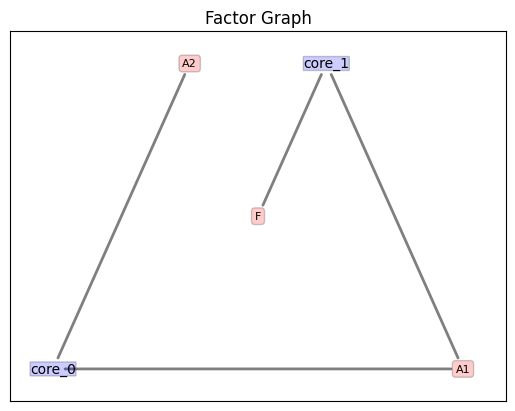

In [6]:
formula_0 = lambda a1, a2: ( a1 ^ a2 )
formula_1 = lambda a1, f: (not f or a1)

kb_tn = {
    "core_0" : representation.create_tensor_encoding(inshape=[2,2],incolors=["A1","A2"],function=formula_0),
    "core_1" : representation.create_tensor_encoding(inshape=[2,2],incolors=["A1","F"],function=formula_1)
}


engine.draw_factor_graph(kb_tn)

In [16]:
kb_tn["core_0"].values

array([[0., 1.],
       [1., 0.]])

We retrieve the tensor by contracting the tensors

In [7]:
kb_retrieved = engine.contract(kb_tn, openColors=["A1","A2","F"])

Investigate, whether the retrieved knowledge base is the same tensor as the directly encoded knowledge base:

In [8]:
kb_retrieved.values

array([[[0., 0.],
        [1., 0.]],

       [[1., 1.],
        [0., 0.]]])

In [9]:
kb_retrieved == kb_tensor

True

# Entailment check


We check entailment based on the contraction of the knowledge base (in tensor network decomposition) with the negated test formula.

In [10]:
def check_entailment(check_formula, check_variables, tensor_network):
  negated_check_formula = lambda *args: not check_formula(*args)

  check_core = representation.create_tensor_encoding(
    inshape=[2 for _ in check_variables],
    incolors=check_variables,
    function=negated_check_formula)
  return not engine.contract({**tensor_network, "check_core" : check_core}, openColors=[])[:]

# Entailment of the formula, that A1 and A2 cannot be true simultaneously:
print(check_entailment(lambda a1, a2 : not (a1 and a2), ["A1","A2"], kb_tn))

# Entailment of the formula, that F is always true:
print(check_entailment(lambda f : f, ["F"], kb_tn))

True
False
